# Config B - Continuous-State ICU-Sepsis (Deep RL)

This notebook **only calls** the implementation in [`sepsis_rl.py`](sepsis_rl.py).
All the agent / training / evaluation / plotting logic lives there; here we just
run it and look at the results. Every figure is saved to the **`outputs/`** directory.

**Action space is `Discrete(25)`** (5 vasopressor x 5 IV-fluid levels) - the same as
Config A. What is continuous in Config B is the **observation** (47-dim clinical
feature vector). We therefore use the discrete-action algorithms **DQN, PPO, A2C**.

| Run | Normalization | Purpose |
|-----|---------------|---------|
| DQN, PPO (v1) | none | baseline on raw observations |
| DQN-v2, PPO-v2, A2C | VecNormalize | clean ablation: effect of obs normalization |

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import sepsis_rl as srl

srl.ensure_dirs(srl.OUTPUT_DIR, srl.MODELS_DIR, srl.LOGS_DIR)
print('Device           :', srl.DEVICE)
print('Plots saved to   :', srl.OUTPUT_DIR + '/')
print('Algorithms       :', list(srl.ALGOS))

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Device           : cuda
Plots saved to   : outputs/
Algorithms       : ['DQN', 'PPO', 'A2C']


## 1. Environment & random baseline

The full clinical environment (`make_clinical_env`) stacks three failure-mode
wrappers on top of the continuous base env: episodic observation noise, episodic
missing labs, and rare acute death events. The random policy is the target to beat.

In [2]:
from envs.wrappers import make_clinical_env

env = make_clinical_env()
print('Observation space:', env.observation_space)
print('Action space     :', env.action_space)
env.close()

# Random baseline (use 1000 episodes for the report)
random_stats = srl.random_baseline(n_episodes=1000)
RANDOM_RETURN = random_stats['return']

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Observation space: Box(-inf, inf, (47,), float32)
Action space     : Discrete(25)
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[random] return=0.5674  survival=66.3%


## 2. Training

`TIMESTEPS` controls the budget. Default is **fast** (a few minutes per agent).
For final, report-quality results set it to `1_000_000` (several hours total).

In [3]:
TIMESTEPS = 150_000      # <- para resultados finais usa 1_000_000
EVAL_FREQ = 5_000
N_EVAL    = 200           # aumentado de 50 para curvas mais suaves

# --- v1: raw observations (no normalization) ---
_, dqn_tag = srl.train_agent('DQN', timesteps=TIMESTEPS, normalize=False,
                             eval_freq=EVAL_FREQ, n_eval_episodes=N_EVAL)
_, ppo_tag = srl.train_agent('PPO', timesteps=TIMESTEPS, normalize=False,
                             eval_freq=EVAL_FREQ, n_eval_episodes=N_EVAL)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


Output()

[dqn] training complete (150,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


Output()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[ppo] training complete (150,000 steps).


### v2: with `VecNormalize`

The 47 features live on wildly different scales, so normalizing observations is the
single biggest lever for these agents. v2 changes **only** the normalization vs v1.

In [4]:
_, dqn2_tag = srl.train_agent('DQN', timesteps=TIMESTEPS, normalize=True,
                             eval_freq=EVAL_FREQ, n_eval_episodes=N_EVAL)
_, ppo2_tag = srl.train_agent('PPO', timesteps=TIMESTEPS, normalize=True,
                             eval_freq=EVAL_FREQ, n_eval_episodes=N_EVAL)
_, a2c_tag  = srl.train_agent('A2C', timesteps=TIMESTEPS, normalize=True,
                             eval_freq=EVAL_FREQ, n_eval_episodes=N_EVAL)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


Output()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[dqn_v2] training complete (150,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


Output()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[ppo_v2] training complete (150,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


Output()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[a2c_v2] training complete (150,000 steps).


## 3. Learning curves

Read from each run's `evaluations.npz`, EMA-smoothed (faint line = raw eval returns).

Saved outputs\configB_learning_curves.png


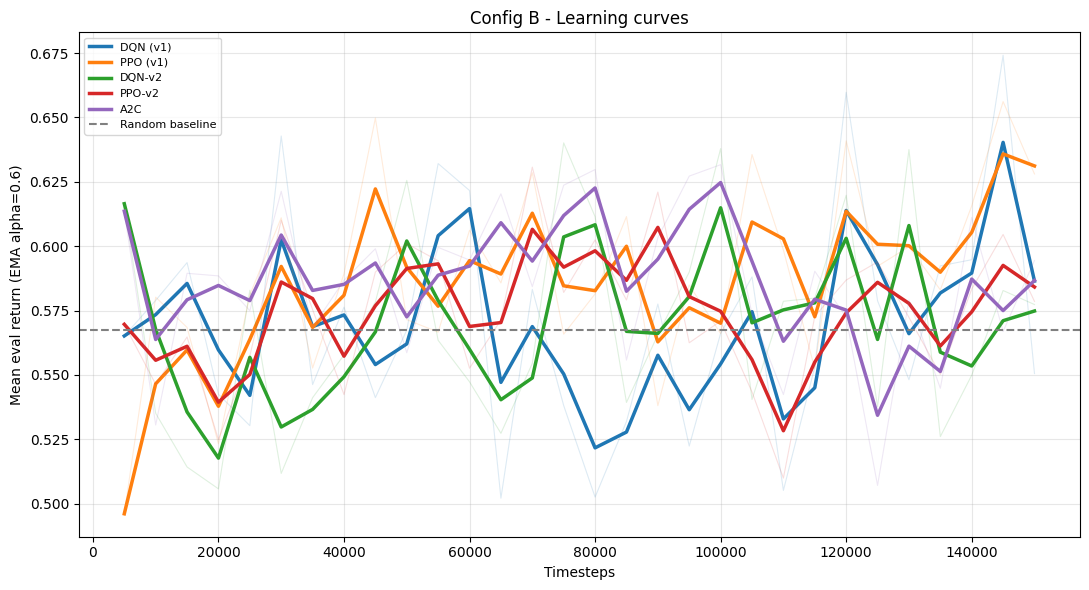

Saved outputs\configB_learning_curves_zoom.png


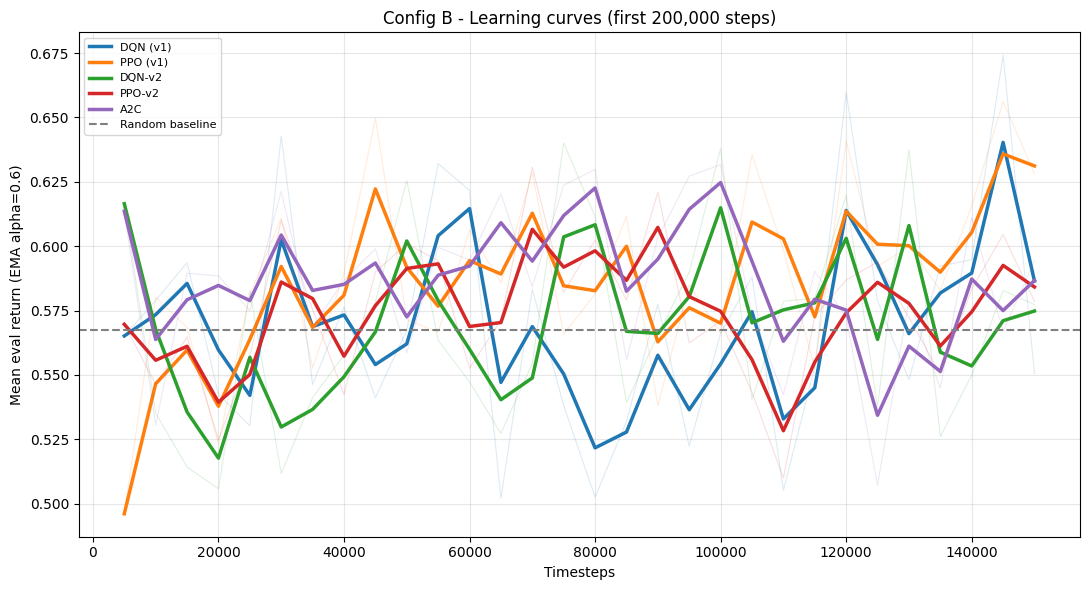

'outputs\\configB_learning_curves_zoom.png'

In [5]:
# Curva completa (todos os passos)
srl.plot_learning_curves(
    {dqn_tag: 'DQN (v1)', ppo_tag: 'PPO (v1)',
     dqn2_tag: 'DQN-v2', ppo2_tag: 'PPO-v2', a2c_tag: 'A2C'},
    baseline=RANDOM_RETURN,
)

# Zoom nos primeiros 200k passos - onde a aprendizagem acontece
srl.plot_learning_curves(
    {dqn_tag: 'DQN (v1)', ppo_tag: 'PPO (v1)',
     dqn2_tag: 'DQN-v2', ppo2_tag: 'PPO-v2', a2c_tag: 'A2C'},
    baseline=RANDOM_RETURN,
    zoom_steps=200_000,
    filename='configB_learning_curves_zoom.png',
)

## 4. Robustness evaluation

Each agent is evaluated on its own env per failure mode (Clean / Noisy / Missing /
Acute / All). Survival is read from the terminal reward (death -> 0, survival -> ~1).

In [6]:
N_EVAL_EPISODES = 1000     # 1000 for the report

results = {
    'DQN (v1)': srl.evaluate_conditions(dqn_tag,  'DQN', n_episodes=N_EVAL_EPISODES),
    'PPO (v1)': srl.evaluate_conditions(ppo_tag,  'PPO', n_episodes=N_EVAL_EPISODES),
    'DQN-v2':   srl.evaluate_conditions(dqn2_tag, 'DQN', n_episodes=N_EVAL_EPISODES),
    'PPO-v2':   srl.evaluate_conditions(ppo2_tag, 'PPO', n_episodes=N_EVAL_EPISODES),
    'A2C':      srl.evaluate_conditions(a2c_tag,  'A2C', n_episodes=N_EVAL_EPISODES),
}

srl.results_table(results, random_ret=RANDOM_RETURN, condition='All')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[dqn] All      n=1000  return=0.5638  survival=64.1% (+/-3.0)  intensity=0.436
[dqn] Clean    n= 649  return=0.6428  survival=72.1% (+/-3.3)  intensity=0.436
[dqn] Noisy    n= 141  return=0.5831  survival=66.0% (+/-7.4)  intensity=0.461
[dqn] Missing  n= 152  return=0.5431  survival=61.2% (+/-7.9)  intensity=0.429
[dqn] Acute    n= 105  return=-0.0820  survival=0.0% (+/-0.0)  intensity=0.420
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[ppo] All      n=1000  return=0.5977  survival=66.2% (+/-2.9)  intensity=0.375
[ppo] Clean    n= 663  return=0.6737  survival=73.8% (+/-3.2)  intensity=0.377
[ppo] Noisy    n= 157  return=0.6126  survival=67.5% (+/-7.3)  intensity=0.359
[ppo] Missing  n= 153  return=0.4593  survival=52.3% (+/-7.8)  intensity=0.361
[ppo] Acute    n=  82  return=-0.0679  survival=0.0% (+/-0.0)  intens

,Agent,Return (All),Survival (All),Intensity (All),vs Random
0,DQN (v1),0.5638,64.1% +/- 3.0,0.436,-0.6%
1,PPO (v1),0.5977,66.2% +/- 2.9,0.375,+5.3%
2,DQN-v2,0.5591,65.1% +/- 3.0,0.484,-1.5%
3,PPO-v2,0.5865,66.8% +/- 2.8,0.454,+3.4%
4,A2C,0.5852,65.1% +/- 2.9,0.364,+3.1%


Saved outputs\configB_robustness_return.png


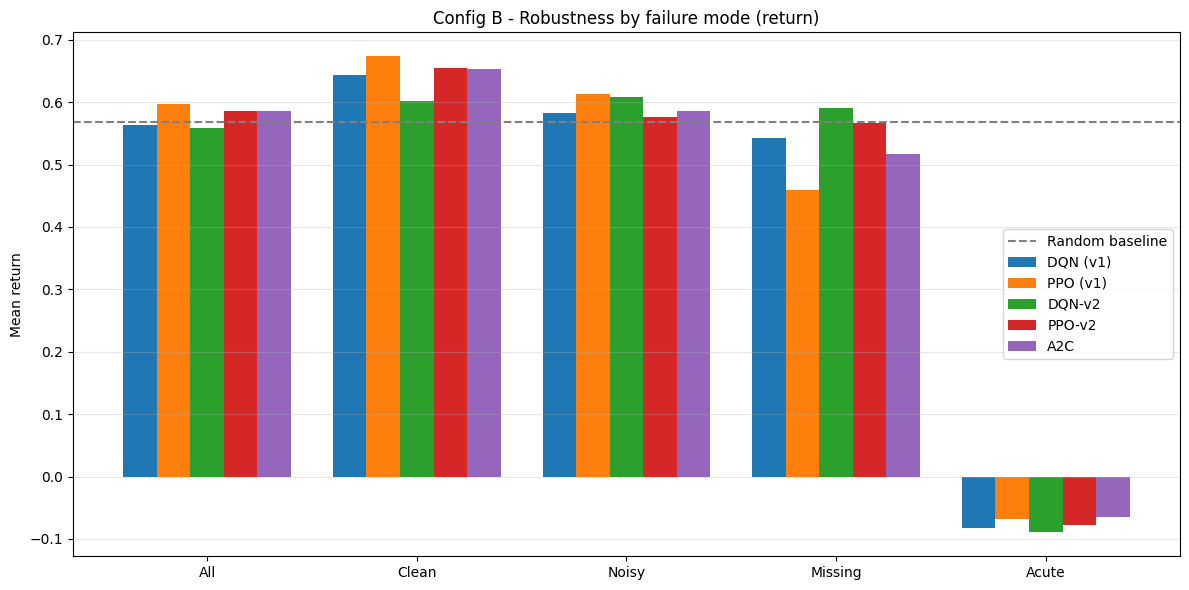

Saved outputs\configB_robustness_survival.png


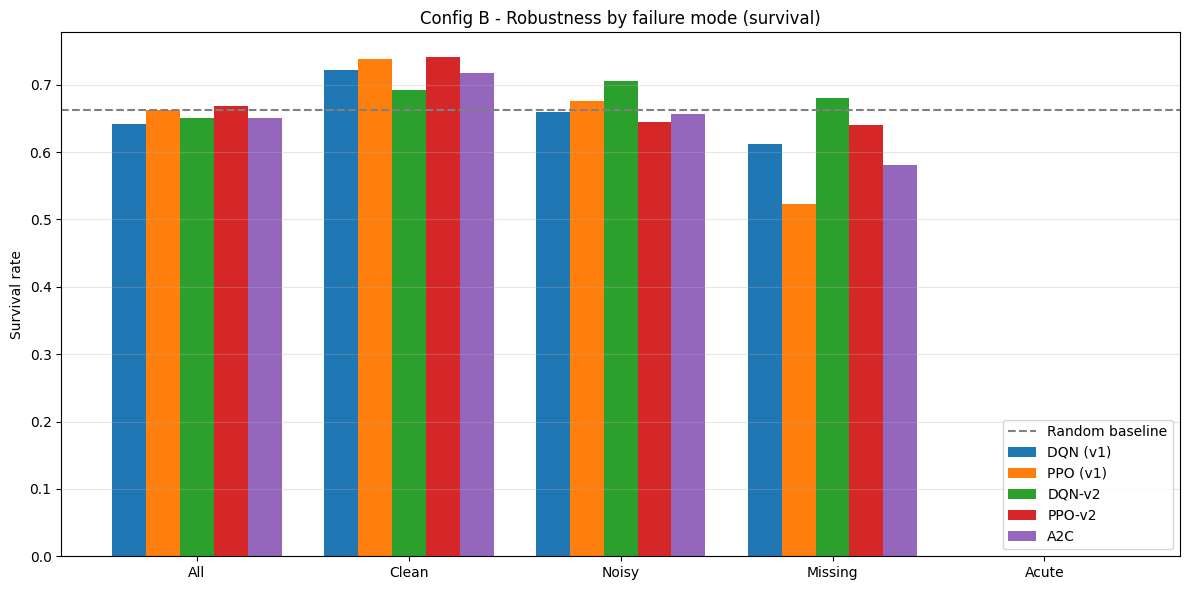

'outputs\\configB_robustness_survival.png'

In [7]:
srl.plot_robustness(results, metric='return',   baseline=RANDOM_RETURN,
                    filename='configB_robustness_return.png')
srl.plot_robustness(results, metric='survival', baseline=random_stats['survival'],
                    filename='configB_robustness_survival.png')

## 5. Optional hyperparameter tuning (Optuna)

This section is intentionally disabled by default so the notebook can run end-to-end in a reasonable time. Set `RUN_OPTUNA=True` to run the short proxy search, and set `RUN_TUNED=True` only after Optuna if you want full-budget tuned training.


In [8]:
RUN_OPTUNA = False  # Set True only when you want the extra hyperparameter-search run.
studies = {}

if RUN_OPTUNA:
    for algo in ["DQN", "PPO", "A2C"]:
        studies[algo] = srl.tune(algo, n_trials=15, timesteps=50_000, normalize=True)
        srl.save_optuna_plots(studies[algo], name=algo)

    for algo, study in studies.items():
        print(f"{algo}: best return={study.best_value:.4f}  params={study.best_params}")

    import json as _json
    with open("optuna_best_params.json", "w") as f:
        _json.dump({algo: study.best_params for algo, study in studies.items()}, f, indent=2)
    print("Best params saved to optuna_best_params.json")
else:
    print("Optuna skipped. Set RUN_OPTUNA=True for the optional hyperparameter search.")


Optuna skipped. Set RUN_OPTUNA=True for the optional hyperparameter search.


In [9]:
if RUN_OPTUNA:
    srl.plot_best_trial_curves(
        ['DQN', 'PPO', 'A2C'],
        baseline=RANDOM_RETURN,
    )
else:
    print("Best-trial curve skipped because RUN_OPTUNA=False.")


Best-trial curve skipped because RUN_OPTUNA=False.


### Optional full-budget retraining

Plug Optuna's best hyperparameters into a full-budget run. This is disabled by default because it can take several hours.


In [10]:
RUN_TUNED = False  # Set True after RUN_OPTUNA=True if you want full-budget tuned training.
TIMESTEPS_TUNED = 1_000_000

tuned_tags = {}

if RUN_TUNED:
    if not studies:
        raise RuntimeError("Run Optuna first: set RUN_OPTUNA=True and execute the tuning cell.")

    for best_algo in ['DQN', 'PPO', 'A2C']:
        best_hp = dict(studies[best_algo].best_params)
        _, tag = srl.train_agent(
            best_algo, timesteps=TIMESTEPS_TUNED, normalize=True,
            hyperparams=best_hp, tag=f'{best_algo.lower()}_tuned',
            eval_freq=EVAL_FREQ, n_eval_episodes=N_EVAL,
        )
        tuned_tags[best_algo] = tag

    srl.plot_learning_curves(
        {tuned_tags["DQN"]: "DQN (tuned)",
         tuned_tags["PPO"]: "PPO (tuned)",
         tuned_tags["A2C"]: "A2C (tuned)"},
        baseline=RANDOM_RETURN,
        zoom_steps=TIMESTEPS_TUNED,
        filename="configB_all_tuned_curves.png",
    )

    srl.plot_learning_curves(
        {tuned_tags["DQN"]: "DQN (tuned)",
         tuned_tags["PPO"]: "PPO (tuned)",
         tuned_tags["A2C"]: "A2C (tuned)"},
        baseline=RANDOM_RETURN,
        zoom_steps=300_000,
        filename="configB_all_tuned_curves_zoom.png",
    )

    results_tuned = {
        f"{algo} (tuned)": srl.evaluate_conditions(tag, algo, n_episodes=N_EVAL_EPISODES)
        for algo, tag in tuned_tags.items()
    }
    display(srl.results_table(results_tuned, random_ret=RANDOM_RETURN))
    srl.plot_robustness(results_tuned, metric="return", baseline=RANDOM_RETURN,
                        filename="configB_tuned_robustness.png")
else:
    print("Full-budget tuned training skipped. Set RUN_TUNED=True after running Optuna.")


Full-budget tuned training skipped. Set RUN_TUNED=True after running Optuna.


In [11]:
if tuned_tags:
    for algo, tag in tuned_tags.items():
        srl.plot_learning_curves(
            {tag: f"{algo} (tuned)"},
            baseline=RANDOM_RETURN,
            show_trend=True,
            filename=f"configB_{algo.lower()}_tuned_trend.png",
        )
else:
    print("Tuned trend plots skipped because RUN_TUNED=False.")


Tuned trend plots skipped because RUN_TUNED=False.


In [12]:
if tuned_tags:
    srl.plot_curves_grid(
        {'dqn_tuned': 'DQN (tuned)',
         'ppo_tuned': 'PPO (tuned)',
         'a2c_tuned': 'A2C (tuned)'},
        baseline=RANDOM_RETURN,
        filename='configB_tuned_grid.png',
    )
else:
    print("Tuned grid plot skipped because RUN_TUNED=False.")


Tuned grid plot skipped because RUN_TUNED=False.


## 6. Creative extension - robustness + clinical interpretability

Our creative extension audits the trained agents along two clinical axes:

1. **Robustness** under the three failure modes (Clean / Noisy / Missing / Acute) -
   already computed above via `evaluate_conditions` and `plot_robustness`.
2. **Interpretability**: (a) the *treatment-intensity* and *dose grid* each policy
   prescribes, and (b) *feature importance* of the DQN Q-network - which of the 47
   clinical variables actually drive its decisions.

This connects the learned policies back to clinical meaning (the whole point of the
`lam` parsimony penalty and the sepsis-severity features) and does so **without**
altering the required environment.

### 6.1 Treatment intensity & dose grid

Lower intensity at equal survival is clinically preferable. The 5x5 grid shows what each policy actually prescribes (vasopressor x IV fluid).

Saved outputs\configB_intensity.png


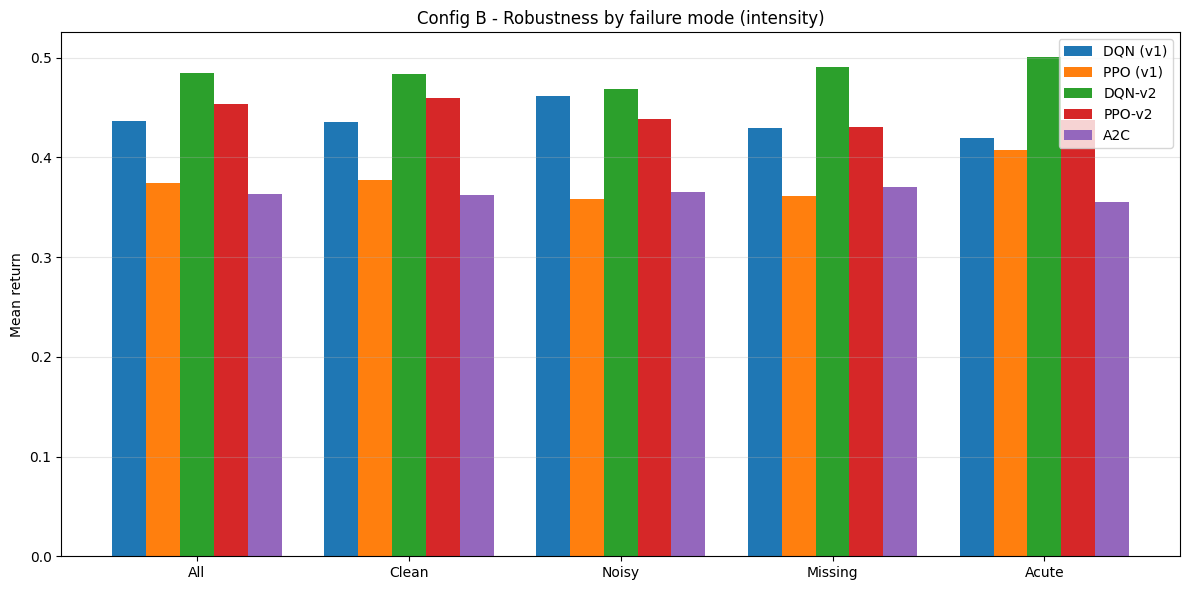

Saved outputs\configB_dose_grid.png


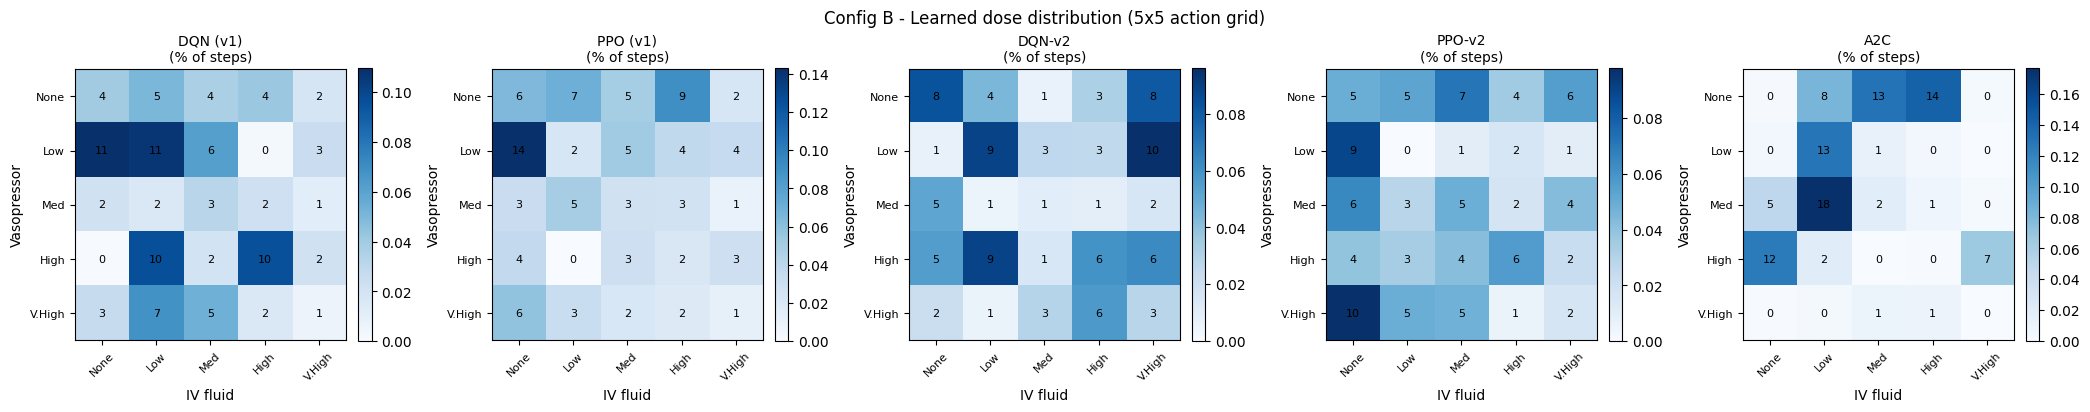

'outputs\\configB_dose_grid.png'

In [13]:
# Mean treatment intensity per failure mode (already collected during evaluation)
srl.plot_robustness(results, metric='intensity', baseline=None,
                    filename='configB_intensity.png')

# 5x5 dose grid (vasopressor x IV fluid) for every agent
srl.plot_dose_grid(results, filename='configB_dose_grid.png')

### 6.2 DQN feature importance (Q-value perturbation)

Permute each feature and measure the mean |Delta Q| on the chosen action. Red bars = established sepsis-severity markers; a credible agent should rely on them.

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Saved outputs\configB_feature_importance.png
Top 10 decision-relevant features:
   1. Weight           0.06287
   2. Milrinone        0.06252
   3. Insulin          0.05547
   4. WBC              0.05251
   5. Age              0.05168
   6. AST              0.05042
   7. Lactate          0.04852 <- sepsis marker
   8. Dopamine         0.04717
   9. Norepinephrine   0.04685
  10. Phenylephrine    0.04480


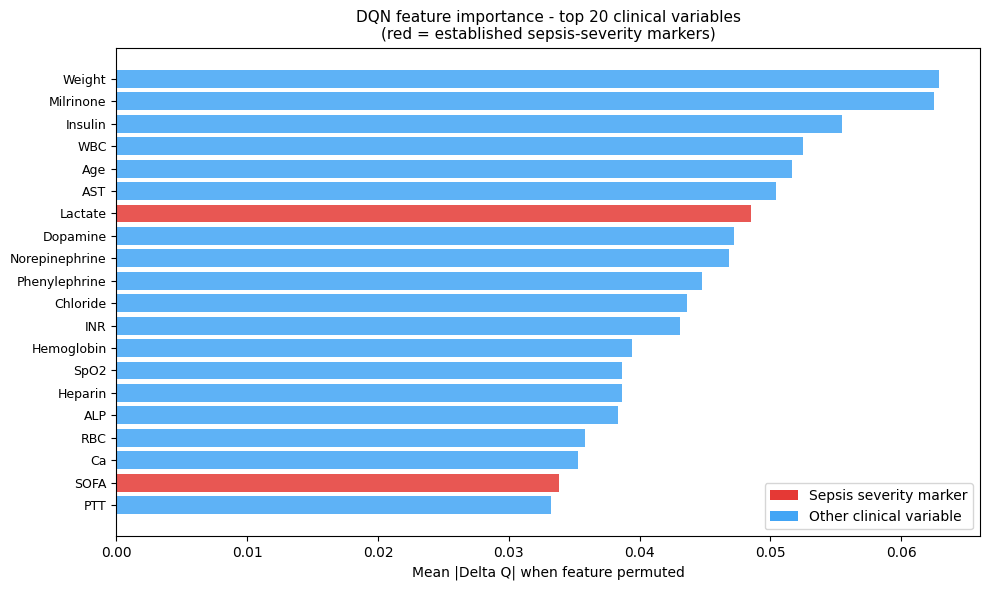

In [14]:
# Use the normalized DQN (dqn2_tag); importance is computed on the same
# normalized inputs the network saw during training.
importances, order = srl.feature_importance_dqn(dqn2_tag, n_states=500, top_n=20)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Saved outputs\configB_shap_importance.png
Top 10 features by SHAP:
   1. Lactate          0.07482 <- sepsis marker
   2. Phenylephrine    0.06928
   3. AST              0.06476
   4. Milrinone        0.06170
   5. Weight           0.05116
   6. Insulin          0.04937
   7. RespRate         0.04601 <- sepsis marker
   8. INR              0.03819
   9. Dopamine         0.03396
  10. Age              0.03236


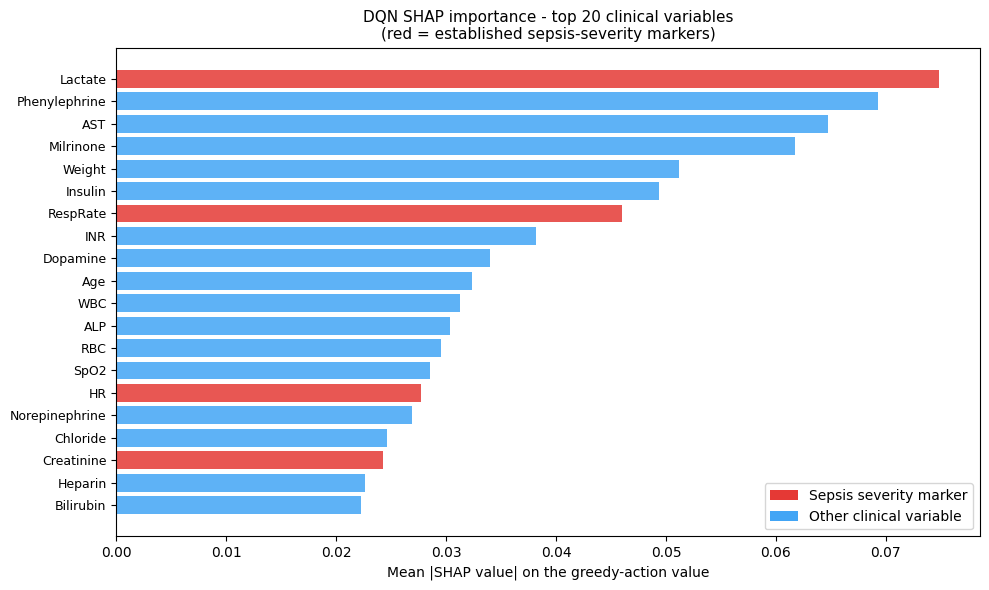

(array([0.01598004, 0.0303616 , 0.01053972, 0.06476374, 0.02226799,
        0.01007824, 0.02462049, 0.02423698, 0.02065246, 0.01471251,
        0.0082873 , 0.02096538, 0.01519906, 0.01164183, 0.0185897 ,
        0.03818761, 0.07482346, 0.0146402 , 0.01813909, 0.0177471 ,
        0.01637011, 0.01830075, 0.01501038, 0.02002217, 0.02950395,
        0.01964721, 0.01584651, 0.01244804, 0.01193036, 0.01940473,
        0.01110004, 0.03128286, 0.05115851, 0.01762949, 0.02265051,
        0.02774899, 0.01543086, 0.0493693 , 0.02690523, 0.01514638,
        0.00765231, 0.03396043, 0.06927622, 0.02850688, 0.06170467,
        0.04601341, 0.032355  ]),
 array([16, 42,  3, 44, 32, 37, 45, 15, 41, 46, 31,  1, 24, 43, 35, 38,  6,
         7, 34,  4, 11,  8, 23, 25, 29, 14, 21, 18, 19, 33, 20,  0, 26, 36,
        12, 39, 22,  9, 17, 27, 28, 13, 30,  2,  5, 10, 40]))

In [15]:
# SHAP attribution on the SAME network as the permutation analysis (dqn2_tag),
# as a principled complement; agreement between the two strengthens the reading.
srl.shap_importance_dqn(dqn2_tag, n_background=100, n_explain=300, top_n=20)

### 6.3 Honest Config A vs Config B comparison

Config A numbers are read from `configA_results.json` (produced by the Config A notebook) - never hard-coded. **Run the Config A notebook first.**

In [16]:
# Cross-config table using REAL Config A metrics from configA_results.json
df_compare = srl.compare_configs(results, configA_path='configA_results.json',
                                 condition='All')
df_compare

,Config,Agent,Return,Survival,Intensity
0,A,Random,0.5877,68.7%,0.494
1,A,Policy Iteration,0.7507,78.8%,0.163
2,A,Q-Learning,0.6115,71.3%,0.486
3,A,SARSA,0.6313,72.6%,0.462
4,B,DQN (v1),0.5638,64.1% +/- 3.0,0.436
5,B,PPO (v1),0.5977,66.2% +/- 2.9,0.375
6,B,DQN-v2,0.5591,65.1% +/- 3.0,0.484
7,B,PPO-v2,0.5865,66.8% +/- 2.8,0.454
8,B,A2C,0.5852,65.1% +/- 2.9,0.364


### 6.4 Reward shaping - redirecting RL from *parsimony* to *survival*

**Diagnosis (the key finding).** Compared against a per-condition **random baseline**
on the same seeds, the unshaped deep agents barely improve *survival*: they mostly
learn to lower *treatment intensity* (which raises return via the `lam` penalty)
rather than to save more patients. The native reward is sparse (+1 at survival),
so the parsimony penalty is the only dense signal and the gradient follows it.

**Fix (theory + practice).** We add **potential-based reward shaping**
(Ng, Harada & Russell, 1999) with potential `Phi(s) = -beta * SOFA(s)`: transitions
that lower the SOFA organ-failure score get an immediate bonus. Potential-based
shaping provably leaves the optimal policy unchanged, so it is a principled way to
densify the signal (reward-design theme of Lab 6) without biasing the objective.

**Brief compliance.** Shaping is applied to the **training** env only
(`SofaShapingEnv`); evaluation always uses the unshaped `make_clinical_env()` and
the true reward, so reported numbers are on the required environment.

First, a **fair** random baseline bucketed by failure mode (same seed scheme as the agents) - this is what every agent must actually beat *per condition*.

In [17]:
# Per-condition reference policies with 95% CIs: the random policy (lower bound)
# and the clinician expert (the AI Clinician behaviour policy).
rand_buckets   = srl.random_baseline_by_condition(n_episodes=1000)
expert_buckets = srl.expert_baseline_by_condition(n_episodes=1000)
results['Random'] = rand_buckets
results['Expert'] = expert_buckets

df_fair = srl.compare_configs(results, configA_path='configA_results.json', condition='All')
df_fair

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[random] All      n=1000  return=0.5439  survival=63.2% (+/-2.9)  intensity=0.497
[random] Clean    n= 650  return=0.6256  survival=71.2% (+/-3.6)  intensity=0.499
[random] Noisy    n= 156  return=0.5034  survival=60.3% (+/-7.7)  intensity=0.502
[random] Missing  n= 143  return=0.5276  survival=62.2% (+/-7.7)  intensity=0.480
[random] Acute    n= 105  return=-0.0734  survival=0.0% (+/-0.0)  intensity=0.489
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[expert] All      n=1000  return=0.5926  survival=65.2% (+/-3.0)  intensity=0.307
[expert] Clean    n= 673  return=0.6476  survival=70.6% (+/-3.4)  intensity=0.304
[expert] Noisy    n= 146  return=0.5530  survival=61.6% (+/-7.5)  intensity=0.308
[expert] Missing  n= 156  return=0.5901  survival=65.4% (+/-7.7)  intensity=0.305
[expert] Acute    n=  67  return=-0.0529  

,Config,Agent,Return,Survival,Intensity
0,A,Random,0.5877,68.7%,0.494
1,A,Policy Iteration,0.7507,78.8%,0.163
2,A,Q-Learning,0.6115,71.3%,0.486
3,A,SARSA,0.6313,72.6%,0.462
4,B,DQN (v1),0.5638,64.1% +/- 3.0,0.436
5,B,PPO (v1),0.5977,66.2% +/- 2.9,0.375
6,B,DQN-v2,0.5591,65.1% +/- 3.0,0.484
7,B,PPO-v2,0.5865,66.8% +/- 2.8,0.454
8,B,A2C,0.5852,65.1% +/- 2.9,0.364
9,B,Random,0.5439,63.2% +/- 2.9,0.497


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


Output()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[ppo_v2_shaped] training complete (150,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[ppo_v2_shaped] All      n=1000  return=0.5944  survival=67.9% (+/-2.9)  intensity=0.458
[ppo_v2_shaped] Clean    n= 687  return=0.6481  survival=73.2% (+/-3.2)  intensity=0.461
[ppo_v2_shaped] Noisy    n= 147  return=0.6336  survival=72.1% (+/-7.5)  intensity=0.440
[ppo_v2_shaped] Missing  n= 145  return=0.5138  survival=59.3% (+/-8.3)  intensity=0.463
[ppo_v2_shaped] Acute    n=  70  return=-0.0898  survival=0.0% (+/-0.0)  intensity=0.454
                Agent  Survival % (All)
    Random (bucketed)              63.2
    PPO-v2 (unshaped)              66.8
PPO-v2 + SOFA shaping              67.9
Saved outputs\configB_shaping_survival.png


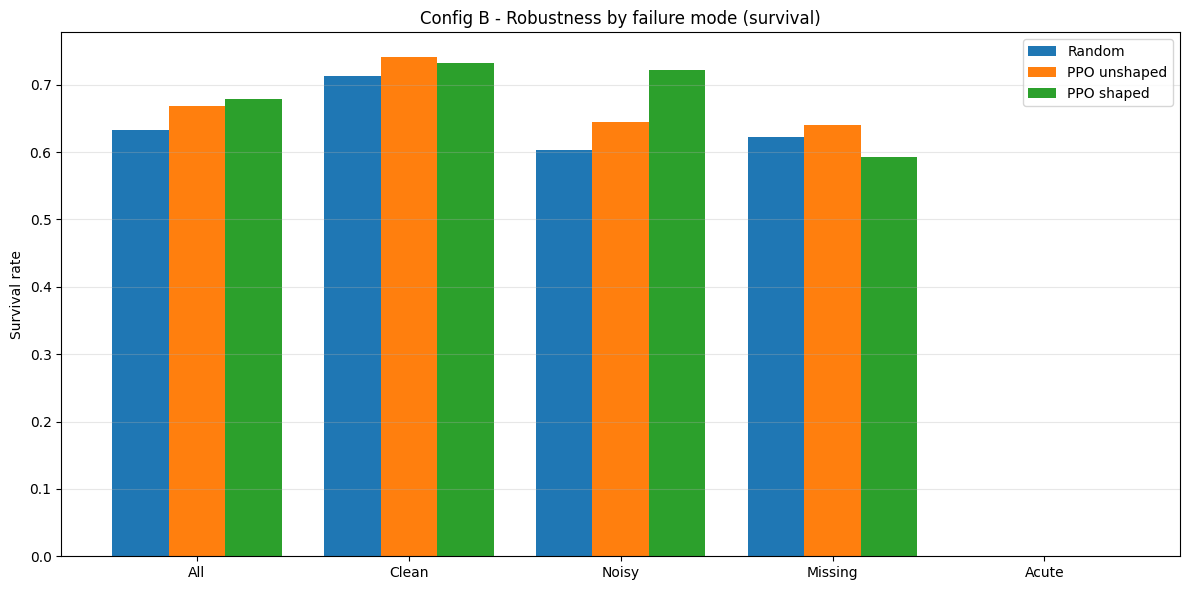

In [18]:
# Creative extension: SOFA reward shaping (training-only). Gated so you control runtime.
RUN_SHAPING = True   # set False to skip; uses the same TIMESTEPS budget as the others

if RUN_SHAPING:
    _, ppo_shaped_tag = srl.train_agent(
        'PPO', timesteps=TIMESTEPS, normalize=True,
        shaping=True, shaping_beta=0.05, tag='ppo_v2_shaped',
        eval_freq=EVAL_FREQ, n_eval_episodes=N_EVAL,
    )
    res_shaped = srl.evaluate_conditions(ppo_shaped_tag, 'PPO', n_episodes=1000)

    # Fair survival comparison: random vs unshaped PPO vs shaped PPO
    import pandas as pd
    def surv(r, b='All'): return round(r[b]['survival'] * 100, 1)
    df_shape = pd.DataFrame(
        [('Random (bucketed)',      surv(rand_buckets)),
         ('PPO-v2 (unshaped)',      surv(results['PPO-v2'])),
         ('PPO-v2 + SOFA shaping',  surv(res_shaped))],
        columns=['Agent', 'Survival % (All)'])
    print(df_shape.to_string(index=False))

    srl.plot_robustness(
        {'Random': rand_buckets, 'PPO unshaped': results['PPO-v2'], 'PPO shaped': res_shaped},
        metric='survival', baseline=None,
        filename='configB_shaping_survival.png')
else:
    print('Reward-shaping experiment skipped (RUN_SHAPING=False).')

### 6.5 Final report results (1M run, reward shaping + tuned)

Loaded from the committed `configB_1m_results.json` so the notebook shows the
same numbers as the report without needing the (git-ignored) 1M models.

,Config,Agent,Return,Survival,Intensity
0,A,Random,0.5877,68.7%,0.494
1,A,Policy Iteration,0.7507,78.8%,0.163
2,A,Q-Learning,0.6115,71.3%,0.486
3,A,SARSA,0.6313,72.6%,0.462
4,B,Random,0.5515,64.2% +/- 2.9,0.497
5,B,Expert,0.6158,67.5% +/- 2.9,0.306
6,B,BC (imitation),0.6001,65.1% +/- 3.0,0.280
7,B,DQN-v2 1M,0.6148,67.7% +/- 2.9,0.369
8,B,PPO-v2 1M,0.6123,66.9% +/- 2.9,0.341
9,B,A2C 1M,0.6261,65.1% +/- 3.0,0.149


Saved outputs\configB_1m_robustness_survival.png


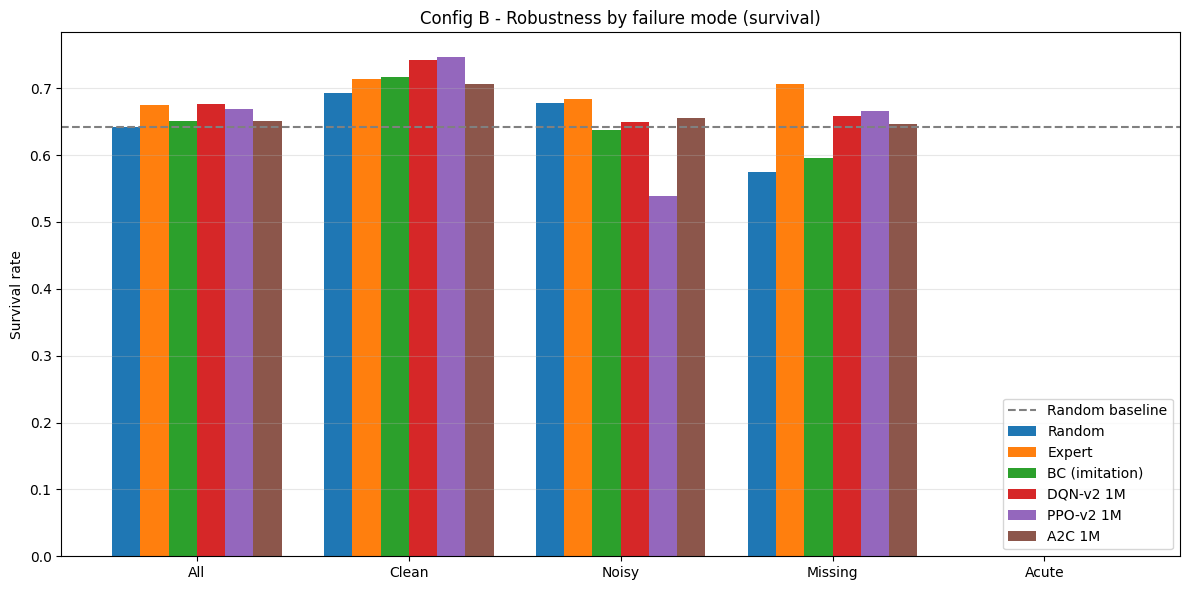

'outputs\\configB_1m_robustness_survival.png'

In [19]:
# Report-quality results come from the 1M-step run (run_configB_1m.py, with SOFA
# reward shaping and the Optuna hyperparameters) and are committed in
# configB_1m_results.json, so the final comparison is shown here without retraining.
import json
summary_1m = json.load(open('configB_1m_results.json'))
order_1m = [('random', 'Random'), ('expert', 'Expert'), ('bc', 'BC (imitation)'),
            ('DQN-v2 1M', 'DQN-v2 1M'), ('PPO-v2 1M', 'PPO-v2 1M'), ('A2C 1M', 'A2C 1M')]
final_1m = {lab: summary_1m[k] for k, lab in order_1m if k in summary_1m}
display(srl.compare_configs(final_1m, configA_path='configA_results.json'))
srl.plot_robustness(final_1m, metric='survival',
                    baseline=final_1m['Random']['All']['survival'],
                    filename='configB_1m_robustness_survival.png')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  BC epoch  10  loss=1.6444  train_acc=0.427
  BC epoch  20  loss=1.6143  train_acc=0.438
  BC epoch  30  loss=1.5931  train_acc=0.441
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[bc] All      n=1000  return=0.6285  survival=67.5% (+/-2.8)  intensity=0.251
[bc] Clean    n= 673  return=0.6654  survival=71.3% (+/-3.4)  intensity=0.250
[bc] Noisy    n= 166  return=0.6419  survival=68.7% (+/-6.9)  intensity=0.255
[bc] Missing  n= 140  return=0.6309  survival=67.1% (+/-7.5)  intensity=0.253
[bc] Acute    n=  58  return=-0.0510  survival=0.0% (+/-0.0)  intensity=0.265
Saved outputs\configB_bc_survival.png


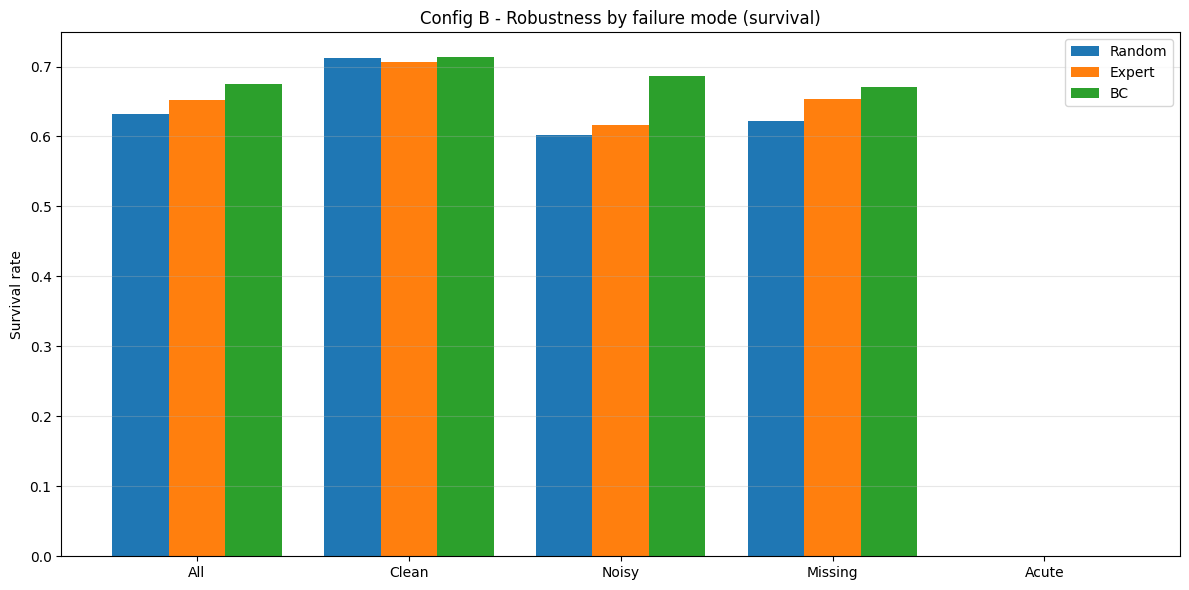

,Config,Agent,Return,Survival,Intensity
0,A,Random,0.5877,68.7%,0.494
1,A,Policy Iteration,0.7507,78.8%,0.163
2,A,Q-Learning,0.6115,71.3%,0.486
3,A,SARSA,0.6313,72.6%,0.462
4,B,Random,0.5439,63.2% +/- 2.9,0.497
5,B,Expert,0.5926,65.2% +/- 3.0,0.307
6,B,BC (imitation),0.6285,67.5% +/- 2.8,0.251


In [20]:
X, y = srl.collect_expert_demonstrations(n_episodes=4000)
bc = srl.train_bc(X, y, epochs=30)
bc_res = srl.evaluate_bc(bc, n_episodes=1000)
srl.plot_robustness({'Random': rand_buckets, 'Expert': expert_buckets, 'BC': bc_res},
                    metric='survival', filename='configB_bc_survival.png')
display(srl.compare_configs({'Random':rand_buckets,'Expert':expert_buckets,'BC (imitation)':bc_res}))